# 04 — Drift Analysis

Computes the **temporal diagnostic profile** for each window pair across all supported model types, then renders a combined dashboard. Reflects the methodology described in the thesis (no drift ratio; per-window baselines reported separately for A and B; global attribution drift restricted to SHAP).

**Model types:** `MODEL_TYPES = ['xgboost', 'logreg', 'mlp_plr']`.
Artifacts are read from `data/models/{model_type}/`, `data/shap/{model_type}/`, and `data/lime/{model_type}/`.

**Input:** `data/processed/`, `data/windows/`, `data/models/{model_type}/`, `data/shap/{model_type}/`, `data/lime/{model_type}/`
**Output per model type:** `data/results/{model_type}/drift_metrics.csv`
**Combined outputs:** `data/results/combined/drift_metrics_combined.csv`, `data/results/combined/final_reporting_plots/*.png`

---

| Metric | Symbol | XGBoost / MLP-PLR (SHAP) | XGBoost / MLP-PLR (LIME) | LR (coef ref) |
|---|---|---|---|---|
| Covariate drift | Δ_X | ✓ | ✓ | ✓ |
| Target drift | Δ_Y | ✓ | ✓ | ✓ |
| Performance change | Δ_perf | ✓ | ✓ | ✓ |
| Local dynamic drift (cosine) | `loc_cos` | ✓ | ✓ | — |
| Local dynamic drift (RBO) | `loc_rbo` | ✓ | ✓ | — |
| Within-window baseline (cosine) — A | `base_cos_A` | ✓ | ✓ | ✓ |
| Within-window baseline (cosine) — B | `base_cos_B` | ✓ | ✓ | ✓ |
| Within-window baseline (RBO) — A | `base_rbo_A` | ✓ | ✓ | ✓ |
| Within-window baseline (RBO) — B | `base_rbo_B` | ✓ | ✓ | ✓ |
| Global attribution drift | `global_rbo` | ✓ (SHAP only) | — | — |
| Explainer stochasticity | `stoch_cos_A/B`, `stoch_rbo_A/B`, `stoch_cos`, `stoch_rbo` | ✓ | ✓ | N/A |
| Full-window LR coef drift | `coef_dyn_cos`, `coef_dyn_rbo` | — | — | ✓ |

## Homesite-specific drift conventions

1. **Combined feature dimension**: explanation arrays from 03 / 03b have shape `(R, n_explained, n_combined)` where `n_combined = n_num + n_bin + n_cat`. Cosine / RBO operate on this larger space. Feature ordering = `feat_names['num'] + feat_names['bin'] + feat_names['cat']`.
2. **Covariate drift on cat features (TV on category frequencies).** Wasserstein on encoded integer codes is meaningless for nominal categoricals — the integer labels are arbitrary frequency-rank assignments by the encoder, so a `W1` gap between codes 2 and 5 has no semantic content. We therefore compute **Total Variation distance** on the empirical category-frequency distributions per cat variable (helper: `total_variation_distance_codes`). Window A's shared `OrdinalEncoder` (loaded from `replicas_A/encoder.joblib`) is applied to both windows so categories are bucketed identically — including the `min_frequency=1/100` infrequent bucket and the `-1` unknown bucket for categories seen in B but not in A. TV is bounded `[0, 1]`, so it composes cleanly with z-scaled-numeric Wasserstein and raw-binary Wasserstein under the per-feature mean that builds `delta_X`.
3. **LR coefficient drift on the `(n_num_bin + n_cat)` axis.** Notebook 02 writes `coef_<side>_ref.npy` with shape `(R, n_num_bin + n_cat)`: numeric coefficients are reprojected to the pair-level reference scaler basis, binary coefficients stay on their raw 0/1 scale, and the categorical block contains the **L2-aggregated dummy coefficients per cat variable** — one number per cat var, not one per dummy. The aggregation is meaningful now that 02's LR pipeline uses one-hot expansion of the shared per-(window, side) encoder, so the dummy column layout is consistent across replicas of the same side.
4. **Class weighting**: every model fed into this notebook is trained with balanced sample weights as part of the operational retraining pipeline (notebooks 02 / 02b, scheme `balanced_sample_weights`). This affects the fitted models — and therefore the SHAP / LIME / coefficient artefacts feeding into all drift metrics — but it does **not** affect any metric reported here. `pr_auc_A`, `pr_auc_B`, `delta_perf`, `delta_X` and `delta_Y` are computed unweighted on the real observed distribution; `loc_*` / `base_*` / `global_rbo` / `coef_dyn_*` operate on attribution / coefficient vectors directly. A and B may have different `{w_pos, w_neg}` weights when their class balance shifts; the realised values are recorded in `data/models/{model_type}/pair_XX/class_weights.json`.

## Output schema

Per pair × (model_type, explainer) the master DataFrame has columns:

- Identifiers: `model_type`, `explainer`, `pair_id`, `step_label_A`, `step_label_B`
- Sizes: `n_train_A`, `n_train_B`, `n_eval`, `n_flagged`, `n_subset`
- Performance / data drift: `pr_auc_A`, `pr_auc_B`, `delta_perf`, `delta_X`, `delta_Y`
- Local attribution drift: `loc_cos`, `loc_rbo`
- Within-window baseline instability: `base_cos_A`, `base_cos_B`, `base_rbo_A`, `base_rbo_B`
- Global SHAP drift: `global_rbo` (NaN for LIME)
- Explainer stochasticity: `stoch_cos_A`, `stoch_cos_B`, `stoch_rbo_A`, `stoch_rbo_B`, `stoch_cos`, `stoch_rbo`, `stoch_n_runs`, `explainer_is_deterministic`
- LR-only: `coef_dyn_cos`, `coef_dyn_rbo`

Files written to `data/results/{model_type}/drift_metrics.csv` and `data/results/combined/drift_metrics_combined.csv`. Final reporting plots saved to `data/results/combined/final_reporting_plots/`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install -q rbo --no-deps

In [3]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
from itertools import combinations
import rbo

WORKSPACE = Path('/content/drive/MyDrive/Thesis/Homesite_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'

# ── Per-model-type base directories ───────────────────────────────────────
MODEL_DIR_BASE   = WORKSPACE / 'data' / 'models'
SHAP_DIR_BASE    = WORKSPACE / 'data' / 'shap'
LIME_DIR_BASE    = WORKSPACE / 'data' / 'lime'
RESULTS_DIR_BASE = WORKSPACE / 'data' / 'results'

# Aliases used by downstream cells
SHAP_DIR    = SHAP_DIR_BASE / 'xgboost'
RESULTS_DIR = RESULTS_DIR_BASE

COMBINED_DIR = RESULTS_DIR_BASE / 'combined'
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

# ── What to compute ───────────────────────────────────────────────────────
MODEL_TYPES = ['xgboost', 'logreg', 'mlp_plr']
EXPLAINERS  = ['shap', 'lime']   # per-row attribution sources to iterate over
                                 # LR emits a 'coef' row handled outside this list

RBO_P = 0.7

print('Imports OK')
print(f'MODEL_TYPES: {MODEL_TYPES}')
print(f'EXPLAINERS : {EXPLAINERS}')

Imports OK
MODEL_TYPES: ['xgboost', 'logreg', 'mlp_plr']
EXPLAINERS : ['shap', 'lime']


In [4]:
X_df = pd.read_parquet(PROC_DIR / 'X.parquet')
Y    = np.load(PROC_DIR / 'Y.npy').astype(np.int8)

X_cat_df = pd.read_parquet(PROC_DIR / 'X_cat.parquet')
X_cat    = np.asarray(X_cat_df, dtype=object)

with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)

feature_names_all = feature_names_json['all']            # = num + bin (matches X.parquet)
feature_names_num = feature_names_json['num']
feature_names_bin = feature_names_json['bin']
feature_names_cat = feature_names_json['cat']
feature_names_combined = feature_names_all + feature_names_cat

assert list(X_df.columns)     == feature_names_all, 'X.parquet column order mismatch.'
assert list(X_cat_df.columns) == feature_names_cat, 'X_cat.parquet column order mismatch.'

X = X_df.values.astype(np.float32)

# Column indices in X (= positions in the combined matrix for num+bin part)
num_col_idx = [feature_names_all.index(fn) for fn in feature_names_num]
bin_col_idx = [i for i in range(len(feature_names_all)) if i not in set(num_col_idx)]

n_num     = len(num_col_idx)
n_bin     = len(bin_col_idx)
n_cat     = len(feature_names_cat)
n_num_bin = X.shape[1]                                    # columns in X.parquet
n_combined = n_num_bin + n_cat                            # columns in attribution arrays from 03/03b
cat_col_idx_combined = list(range(n_num_bin, n_num_bin + n_cat))

# Backwards-compat alias used by Shoppers-style helpers
feature_names = feature_names_combined
n_features    = n_combined

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R     = config['parameters']['R']
pairs = config['pairs']

assert X.shape[0] == Y.shape[0] == X_cat.shape[0]
assert X.shape[1] == n_num_bin
assert len(set(num_col_idx) & set(bin_col_idx)) == 0
assert n_num + n_bin == n_num_bin
assert len(pairs) > 0

print(f'X     : {X.shape}    ({n_num} num + {n_bin} bin)')
print(f'X_cat : {X_cat.shape}  ({n_cat} cat)')
print(f'Combined attribution feature dim: {n_combined}')
print(f'R={R}, {len(pairs)} pairs')

X     : (260753, 329)    (253 num + 76 bin)
X_cat : (260753, 23)  (23 cat)
Combined attribution feature dim: 352
R=2, 4 pairs


## Distance and RBO helper functions

For numeric/binary covariate drift and attribution-vector cosine/RBO, the helpers are general-purpose. The categorical covariate drift uses Total Variation on category-frequency vectors (`total_variation_distance_codes`) — see notebook 04's header for why. LR coefficient cosine/RBO operate on the full `(n_num_bin + n_cat)` axis: the categorical block contains L2-aggregated dummy coefficients per cat variable (computed in 02; one number per cat var).

In [5]:
def cosine_distance(u: np.ndarray, v: np.ndarray) -> float:
    """d_cos(u,v) = 1 - cosine_similarity(u,v).
    Both-zero → 0.0; one-zero one-nonzero → np.nan (excluded by nanmedian aggregation).
    """
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    if norm_u < 1e-12 and norm_v < 1e-12:
        return 0.0
    if norm_u < 1e-12 or norm_v < 1e-12:
        return np.nan
    return float(1.0 - np.dot(u, v) / (norm_u * norm_v))


def rbo_score_local(l1, l2, p=0.9):
    """Simple RBO implementation as fallback."""
    if not l1 or not l2: return 0.0
    n = min(len(l1), len(l2))
    s1, s2 = set(), set()
    agreement = 0.0
    res = 0.0
    for i in range(n):
        s1.add(l1[i])
        s2.add(l2[i])
        agreement = len(s1.intersection(s2)) / (i + 1)
        res += agreement * (p ** i)
    return res * (1 - p)


def rbo_distance(u: np.ndarray, v: np.ndarray, p: float = RBO_P) -> float:
    """d_rbo(u, v) = 1 - RBO(rank(u), rank(v))."""
    u_zero = np.all(np.abs(u) < 1e-12)
    v_zero = np.all(np.abs(v) < 1e-12)
    if u_zero and v_zero:
        return 0.0
    if u_zero or v_zero:
        return np.nan
    rank_u = list(np.argsort(-np.abs(u)))
    rank_v = list(np.argsort(-np.abs(v)))
    score = rbo.RankingSimilarity(rank_u, rank_v).rbo(p=p)
    return float(1.0 - score)


def instance_dynamic_drift(phi_A, phi_B, dist_fn) -> float:
    """Mean over all R×R cross-window pairs of d(φ_A^{(r)}, φ_B^{(s)})."""
    dists = []
    for r in range(R):
        for s in range(R):
            dists.append(dist_fn(phi_A[r], phi_B[s]))
    return float(np.nanmean(dists))


def instance_baseline_instability(phi, dist_fn) -> float:
    """Median over all r < r' pairs of d(φ^{(r)}, φ^{(r')})."""
    dists = []
    for r, r2 in combinations(range(R), 2):
        dists.append(dist_fn(phi[r], phi[r2]))
    return float(np.nanmedian(dists)) if dists else 0.0


def rbo_global_drift(phi_bar_A, phi_bar_B, p: float = RBO_P) -> float:
    """Δ_E^{glob}: 1 − RBO(rank(g_A), rank(g_B)) where g(j) = mean_x |φ̄_j(x)|."""
    g_A = np.abs(phi_bar_A).mean(axis=0)
    g_B = np.abs(phi_bar_B).mean(axis=0)
    rank_A = list(np.argsort(-g_A))
    rank_B = list(np.argsort(-g_B))
    score = rbo.RankingSimilarity(rank_A, rank_B).rbo(p=p)
    return float(1.0 - score)


def explainer_stochasticity_from_runs(phi_runs: np.ndarray) -> dict:
    """Compute explainer-only stochasticity from repeated explainer runs.

    phi_runs shape: (Q, n_instances, n_features). For Q=1 (deterministic), returns 0.
    """
    phi_runs = np.asarray(phi_runs)
    assert phi_runs.ndim == 3, f'Expected (Q, n, p), got {phi_runs.shape}'
    Q, n, _ = phi_runs.shape

    if Q == 1:
        return {'stoch_cos': 0.0, 'stoch_rbo': 0.0}

    inst_cos, inst_rbo = [], []
    for i in range(n):
        cos_vals, rbo_vals = [], []
        for q1, q2 in combinations(range(Q), 2):
            u = phi_runs[q1, i]
            v = phi_runs[q2, i]
            cos_vals.append(cosine_distance(u, v))
            rbo_vals.append(rbo_distance(u, v))
        inst_cos.append(np.nanmedian(cos_vals))
        inst_rbo.append(np.nanmedian(rbo_vals))

    return {
        'stoch_cos': float(np.nanmedian(inst_cos)),
        'stoch_rbo': float(np.nanmedian(inst_rbo)),
    }


def load_explainer_stochasticity(attr_dir: Path, explainer_name: str) -> dict:
    """Load raw stochasticity tensors and compute cosine/RBO diagnostics."""
    stoch_json_path = attr_dir / 'stochasticity.json'

    out = {
        'stoch_cos_A': np.nan, 'stoch_cos_B': np.nan,
        'stoch_rbo_A': np.nan, 'stoch_rbo_B': np.nan,
        'stoch_cos': np.nan,   'stoch_rbo': np.nan,
        'stoch_n_runs': np.nan,
        'explainer_is_deterministic': np.nan,
        # Legacy columns kept so older summary/plot code does not crash.
        'explainer_stoch_max_abs': np.nan,
        'explainer_stoch_median_abs': np.nan,
        'shap_stochasticity': np.nan,
    }

    if not stoch_json_path.exists():
        return out

    with open(stoch_json_path) as f:
        meta = json.load(f)

    out['stoch_n_runs'] = int(meta.get('n_runs', np.nan))
    out['explainer_is_deterministic'] = bool(meta.get('is_deterministic_runs', False))

    if explainer_name == 'shap':
        path_A = attr_dir / 'shap_stoch_A.npy'
        path_B = attr_dir / 'shap_stoch_B.npy'
    elif explainer_name == 'lime':
        path_A = attr_dir / 'lime_stoch_A.npy'
        path_B = attr_dir / 'lime_stoch_B.npy'
    else:
        return out

    if not (path_A.exists() and path_B.exists()):
        return out

    phi_A_runs = np.load(path_A)
    phi_B_runs = np.load(path_B)

    mA = explainer_stochasticity_from_runs(phi_A_runs)
    mB = explainer_stochasticity_from_runs(phi_B_runs)

    out['stoch_cos_A'] = mA['stoch_cos']
    out['stoch_cos_B'] = mB['stoch_cos']
    out['stoch_rbo_A'] = mA['stoch_rbo']
    out['stoch_rbo_B'] = mB['stoch_rbo']
    out['stoch_cos'] = float(np.nanmax([out['stoch_cos_A'], out['stoch_cos_B']]))
    out['stoch_rbo'] = float(np.nanmax([out['stoch_rbo_A'], out['stoch_rbo_B']]))

    return out


def total_variation_distance_codes(codes_A: np.ndarray, codes_B: np.ndarray) -> float:
    """Total Variation distance between empirical category-frequency distributions.

    `codes_A` and `codes_B` are 1-D integer arrays of category codes for the SAME
    cat variable, produced by applying the shared per-(window, side) `OrdinalEncoder`
    to window A and window B respectively. The function builds frequency vectors over
    the union of codes seen in either window — including the -1 unknown bucket and the
    infrequent-bucket index — and returns 0.5 * sum |p_A - p_B|, bounded in [0, 1].

    Semantically valid for nominal categoricals: insensitive to the arbitrary integer
    label that the encoder assigned to each category, unlike Wasserstein on raw codes.
    """
    if codes_A.size == 0 and codes_B.size == 0:
        return 0.0
    all_codes = np.unique(np.concatenate([codes_A, codes_B]))
    counts_A = np.array([float((codes_A == c).sum()) for c in all_codes], dtype=np.float64)
    counts_B = np.array([float((codes_B == c).sum()) for c in all_codes], dtype=np.float64)
    p_A = counts_A / max(float(codes_A.size), 1.0)
    p_B = counts_B / max(float(codes_B.size), 1.0)
    return float(0.5 * np.abs(p_A - p_B).sum())


def load_lr_replica_coefs_reference_basis(pair_dir: Path, side: str) -> np.ndarray:
    """Load LR replica reference-basis coefficients from cache (saved by 02).

    Notebook 02 writes `coef_{side}_ref.npy` with shape `(R, n_num_bin + n_cat)`.
    The categorical block contains the L2-aggregated dummy coefficients per cat
    variable — one number per cat var, not one per dummy. The aggregation is
    well-defined because 02's LR pipeline now uses one-hot expansion of a shared
    per-(window, side) `OrdinalEncoder`, so the dummy column layout is consistent
    across replicas of the same side.
    """
    cached_path = pair_dir / f'coef_{side}_ref.npy'
    if not cached_path.exists():
        raise FileNotFoundError(
            f'{cached_path} not found. Rerun 02 with MODEL_TYPE="logreg" — the '
            'reference-basis cache is required for LR drift analysis.'
        )
    return np.load(cached_path)


def median_pairwise_vector_distance(vecs: np.ndarray, dist_fn) -> float:
    """Median pairwise distance for a collection of vectors, shape (R, p)."""
    vals = [
        dist_fn(vecs[r], vecs[r2])
        for r, r2 in combinations(range(vecs.shape[0]), 2)
    ]
    return float(np.nanmedian(vals)) if vals else 0.0


print('Distance functions defined.')

Distance functions defined.


## Main drift computation loop

For each window pair we compute all metrics and append one row per `(model_type, explainer)` combination to a per-model-type results list.

### Logistic Regression — reference treatment

LR is treated as a transparent reference. Instead of computing post-hoc explanation drift:

- **Within-window baseline**: median pairwise distance over the R replica coefficient vectors (in the common reference basis), reported separately for sides A and B.
- **Full-window dynamic drift**: cosine and RBO between the two deterministic full-window LR coefficient vectors (`coef_A_full_ref.npy`, `coef_B_full_ref.npy`), saved as `coef_dyn_cos` and `coef_dyn_rbo`.

Both run on the `(n_num_bin + n_cat)` axis. Each LR replica's coefficient vector contains: numeric coefs reprojected to the reference scaler basis, binary coefs on the raw 0/1 scale, and per-cat-variable L2-aggregated dummy magnitudes — see notebook 02's design note.

In [6]:
all_results = {}


def _load_attributions(explainer_name, pair_dir, attr_dir, pred_data):
    """Return (attr_A, attr_B, flagged_subset_idx_within_flagged) or None.

    For SHAP: XGBoost runs on the full flagged set; MLP-PLR on a saved subsample.
    For LIME: attr files are (R, |F_lime|, p); lime_flagged_idx.npy stores positions
    within the full flagged set.
    """
    if explainer_name == 'shap':
        a_path = attr_dir / 'shap_A.npy'
        b_path = attr_dir / 'shap_B.npy'
        subset_path = attr_dir / 'mlp_shap_subsample_idx.npy'
        if not (a_path.exists() and b_path.exists()):
            return None
        a = np.load(a_path)
        b = np.load(b_path)
        if subset_path.exists():
            subset = np.load(subset_path).astype(np.int64)
        else:
            subset = np.arange(a.shape[1], dtype=np.int64)
        return a, b, subset

    elif explainer_name == 'lime':
        a_path      = attr_dir / 'lime_A.npy'
        b_path      = attr_dir / 'lime_B.npy'
        subset_path = attr_dir / 'lime_flagged_idx.npy'
        if not (a_path.exists() and b_path.exists() and subset_path.exists()):
            return None
        a = np.load(a_path)
        b = np.load(b_path)
        subset = np.load(subset_path).astype(np.int64)
        return a, b, subset

    raise ValueError(f'Unknown explainer: {explainer_name}')


def _validate_attribution_shapes(attr_A, attr_B, subset, flagged_local_idx,
                                 mt, explainer_name, pid):
    """Fail early if attribution arrays are stale or incompatible."""
    assert attr_A.ndim == 3 and attr_B.ndim == 3, (
        f'{mt}/{explainer_name}/pair {pid:02d}: attribution arrays must be 3-D.'
    )
    assert attr_A.shape == attr_B.shape, (
        f'{mt}/{explainer_name}/pair {pid:02d}: attr_A/attr_B shape mismatch: '
        f'{attr_A.shape} vs {attr_B.shape}'
    )
    assert attr_A.shape[0] == R, (
        f'{mt}/{explainer_name}/pair {pid:02d}: expected R={R}, got {attr_A.shape[0]}'
    )
    assert attr_A.shape[2] == n_combined, (
        f'{mt}/{explainer_name}/pair {pid:02d}: expected {n_combined} features, '
        f'got {attr_A.shape[2]}. Rerun 03/03b after the X_cat preprocessing changes.'
    )
    assert len(subset) == attr_A.shape[1], (
        f'{mt}/{explainer_name}/pair {pid:02d}: subset length {len(subset)} '
        f'does not match attribution instances {attr_A.shape[1]}'
    )
    assert np.all((subset >= 0) & (subset < len(flagged_local_idx))), (
        f'{mt}/{explainer_name}/pair {pid:02d}: subset indices outside flagged_idx.'
    )


def _validate_predictions(pred_data, mt, pid, idx_eval):
    required_keys = [
        'preds_A', 'preds_B', 'p_hat_A', 'p_hat_B',
        'flagged_idx', 'Y_eval',
        'pr_auc_A', 'pr_auc_B',
        'per_replica_pr_auc_A', 'per_replica_pr_auc_B',
    ]
    missing = [k for k in required_keys if k not in pred_data.files]
    assert not missing, f'{mt}/pair {pid:02d}: predictions.npz missing keys: {missing}'
    flagged_idx = pred_data['flagged_idx']
    assert pred_data['preds_A'].shape == pred_data['preds_B'].shape
    assert pred_data['preds_A'].shape[0] == R
    assert pred_data['preds_A'].shape[1] == len(idx_eval)
    assert np.all((flagged_idx >= 0) & (flagged_idx < len(idx_eval)))


def _attribution_drift_metrics(attr_A: np.ndarray, attr_B: np.ndarray) -> dict:
    """Compute local drift, separate A/B baselines, and global drift."""
    n_sub = attr_A.shape[1]
    out = {}

    dyn_cos_per_instance = []
    dyn_rbo_per_instance = []
    for i in range(n_sub):
        phi_A_i = attr_A[:, i, :]
        phi_B_i = attr_B[:, i, :]
        dyn_cos_per_instance.append(instance_dynamic_drift(phi_A_i, phi_B_i, cosine_distance))
        dyn_rbo_per_instance.append(instance_dynamic_drift(phi_A_i, phi_B_i, rbo_distance))
    out['loc_cos'] = float(np.nanmedian(dyn_cos_per_instance))
    out['loc_rbo'] = float(np.nanmedian(dyn_rbo_per_instance))

    base_cos_A_per, base_cos_B_per = [], []
    base_rbo_A_per, base_rbo_B_per = [], []
    for i in range(n_sub):
        phi_A_i = attr_A[:, i, :]
        phi_B_i = attr_B[:, i, :]
        base_cos_A_per.append(instance_baseline_instability(phi_A_i, cosine_distance))
        base_cos_B_per.append(instance_baseline_instability(phi_B_i, cosine_distance))
        base_rbo_A_per.append(instance_baseline_instability(phi_A_i, rbo_distance))
        base_rbo_B_per.append(instance_baseline_instability(phi_B_i, rbo_distance))
    out['base_cos_A'] = float(np.nanmedian(base_cos_A_per))
    out['base_cos_B'] = float(np.nanmedian(base_cos_B_per))
    out['base_rbo_A'] = float(np.nanmedian(base_rbo_A_per))
    out['base_rbo_B'] = float(np.nanmedian(base_rbo_B_per))

    phi_bar_A = attr_A.mean(axis=0)
    phi_bar_B = attr_B.mean(axis=0)
    out['global_rbo'] = rbo_global_drift(phi_bar_A, phi_bar_B)

    return out


def _make_base_row(mt, pid, p, pred_data, idx_A, idx_B, flagged_local_idx):
    """Per-pair metrics that are explainer-independent (data drift, target drift, perf).

    Covariate drift (`delta_X`) is computed feature-by-feature, with a metric chosen
    per feature type so that each contribution lives on a comparable scale:
      - numeric features    : Wasserstein on `reference_scaler.transform(X[idx_A/B][:, num_col_idx])`
      - binary features     : Wasserstein on raw 0/1
      - categorical features: Total Variation on category-frequency vectors after applying
                              window-A's shared `OrdinalEncoder` to both windows (loaded from
                              `replicas_A/encoder.joblib`, with `reference_encoder.joblib`
                              as a backwards-compat fallback). TV is bounded [0, 1] and
                              respects nominal semantics.
    `delta_X` is the unweighted mean over all `n_combined` features.
    """
    row = {
        'model_type':    mt,
        'explainer':     None,
        'pair_id':       pid,
        'step_label_A':  p['step_label_A'],
        'step_label_B':  p['step_label_B'],
        'n_train_A':     p['n_train_A'],
        'n_train_B':     p['n_train_B'],
        'n_eval':        p['n_eval'],
        'n_flagged':     len(flagged_local_idx),
        'pr_auc_A':      float(pred_data['pr_auc_A']),
        'pr_auc_B':      float(pred_data['pr_auc_B']),
    }
    row['delta_perf'] = float(pred_data['pr_auc_B']) - float(pred_data['pr_auc_A'])
    row['delta_Y']    = abs(float(Y[idx_A].mean()) - float(Y[idx_B].mean()))

    pair_dir = MODEL_DIR_BASE / mt / f'pair_{pid:02d}'
    reference_scaler_path = pair_dir / 'reference_scaler.joblib'
    # Window-A's shared encoder is the canonical reference for cat drift; fall back
    # to the legacy `reference_encoder.joblib` alias for older 02/02b runs.
    encoder_path = pair_dir / 'replicas_A' / 'encoder.joblib'
    if not encoder_path.exists():
        encoder_path = pair_dir / 'reference_encoder.joblib'

    if reference_scaler_path.exists():
        reference_scaler = joblib.load(reference_scaler_path)
        X_A_num_sc = reference_scaler.transform(X[idx_A][:, num_col_idx])
        X_B_num_sc = reference_scaler.transform(X[idx_B][:, num_col_idx])

        # Per-feature drift on (n_combined,) axis.
        # Numerics  : Wasserstein on reference-scaler-transformed columns.
        # Binaries  : Wasserstein on raw 0/1 columns.
        # Categoricals: Total Variation on category-frequency vectors after applying
        # window-A's shared encoder to both windows (so categories are bucketed identically,
        # including the min_frequency=1/100 infrequent bucket and the -1 unknown bucket).
        w1_per_feat = np.zeros(n_combined, dtype=np.float64)
        for k, j in enumerate(num_col_idx):
            w1_per_feat[j] = wasserstein_distance(X_A_num_sc[:, k], X_B_num_sc[:, k])
        for j in bin_col_idx:
            w1_per_feat[j] = wasserstein_distance(X[idx_A][:, j], X[idx_B][:, j])

        if encoder_path.exists():
            encoder = joblib.load(encoder_path)
            codes_A = encoder.transform(X_cat[idx_A]).astype(np.int64)
            codes_B = encoder.transform(X_cat[idx_B]).astype(np.int64)
            for k, j in enumerate(cat_col_idx_combined):
                w1_per_feat[j] = total_variation_distance_codes(codes_A[:, k], codes_B[:, k])
        else:
            print(f'  WARNING: shared encoder for cat drift missing for {mt}/pair {pid:02d}; '
                  'cat covariate drift defaults to 0 for this pair.')

        row['delta_X'] = float(w1_per_feat.mean())
    else:
        row['delta_X'] = np.nan

    return row


def _fmt(v, w=6, p=4):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return f'{"-":>{w}s}'
    return f'{v:{w}.{p}f}'


# ═════════════════════════════════════════════════════════════════════════
# Main loop
# ═════════════════════════════════════════════════════════════════════════

for mt in MODEL_TYPES:
    print(f'\n{"="*60}')
    print(f'  Model type: {mt}')
    print(f'{"="*60}')

    mt_model_dir = MODEL_DIR_BASE / mt
    results = []

    for p in pairs:
        pid      = p['pair_id']
        pair_dir = mt_model_dir / f'pair_{pid:02d}'

        print(f'\n── [{mt}] Pair {pid:02d}: A_end={p["step_label_A"]}  B_end={p["step_label_B"]} ──')

        pred_data_path = pair_dir / 'predictions.npz'
        if not pred_data_path.exists():
            print(f'  WARNING: predictions.npz not found for pair {pid:02d}. Skipping.')
            continue

        pred_data = np.load(pred_data_path)
        idx_A    = np.array(p['idx_A'],    dtype=np.int64)
        idx_B    = np.array(p['idx_B'],    dtype=np.int64)
        idx_eval = np.array(p['idx_eval'], dtype=np.int64)
        _validate_predictions(pred_data, mt, pid, idx_eval)

        flagged_local_idx = pred_data['flagged_idx']
        n_flagged = len(flagged_local_idx)
        print(f'  Flagged: {n_flagged:,}')

        base_row = _make_base_row(mt, pid, p, pred_data, idx_A, idx_B, flagged_local_idx)
        print(f'  Perf: Δ={base_row["delta_perf"]:+.4f}   Target drift: {base_row["delta_Y"]:.4f}   '
              f'Cov drift: {base_row["delta_X"]:.4f}')

        # ──────────────────────────────────────────────────────────────────
        # LR reference path
        # ──────────────────────────────────────────────────────────────────
        if mt == 'logreg':
            row = dict(base_row)
            row['explainer'] = 'coef'
            row['n_subset'] = np.nan

            # LR has no explainer-side stochasticity.
            row['stoch_cos_A'] = np.nan; row['stoch_cos_B'] = np.nan
            row['stoch_rbo_A'] = np.nan; row['stoch_rbo_B'] = np.nan
            row['stoch_cos']   = np.nan; row['stoch_rbo']   = np.nan
            row['stoch_n_runs'] = np.nan
            row['explainer_is_deterministic'] = True
            row['explainer_stoch_max_abs']    = np.nan
            row['explainer_stoch_median_abs'] = np.nan
            row['shap_stochasticity']         = np.nan

            # LR is not a local post-hoc explainer stream.
            row['loc_cos']    = np.nan
            row['loc_rbo']    = np.nan
            row['global_rbo'] = np.nan

            try:
                coef_A_ref = load_lr_replica_coefs_reference_basis(pair_dir, side='A')
                coef_B_ref = load_lr_replica_coefs_reference_basis(pair_dir, side='B')

                row['base_cos_A'] = median_pairwise_vector_distance(coef_A_ref, cosine_distance)
                row['base_cos_B'] = median_pairwise_vector_distance(coef_B_ref, cosine_distance)
                row['base_rbo_A'] = median_pairwise_vector_distance(coef_A_ref, rbo_distance)
                row['base_rbo_B'] = median_pairwise_vector_distance(coef_B_ref, rbo_distance)
            except Exception as e:
                print(f'  WARNING: could not compute LR reference-basis baselines: {e}')
                row['base_cos_A'] = np.nan; row['base_cos_B'] = np.nan
                row['base_rbo_A'] = np.nan; row['base_rbo_B'] = np.nan

            full_A_path = pair_dir / 'coef_A_full_ref.npy'
            full_B_path = pair_dir / 'coef_B_full_ref.npy'
            if full_A_path.exists() and full_B_path.exists():
                coef_A_full_ref = np.load(full_A_path)
                coef_B_full_ref = np.load(full_B_path)
                row['coef_dyn_cos'] = cosine_distance(coef_A_full_ref, coef_B_full_ref)
                row['coef_dyn_rbo'] = rbo_distance(coef_A_full_ref, coef_B_full_ref)
            else:
                row['coef_dyn_cos'] = np.nan
                row['coef_dyn_rbo'] = np.nan
                print(f'  WARNING: full-window LR reference coefficients missing for pair {pid:02d}.')

            print(f'  [coef]  baseline cos: A={_fmt(row["base_cos_A"])}  B={_fmt(row["base_cos_B"])}  '
                  f'full-window dyn={_fmt(row["coef_dyn_cos"])}')
            print(f'          baseline rbo: A={_fmt(row["base_rbo_A"])}  B={_fmt(row["base_rbo_B"])}  '
                  f'full-window dyn={_fmt(row["coef_dyn_rbo"])}')

            results.append(row)

        # ──────────────────────────────────────────────────────────────────
        # Explainer-based rows (skipped for LR)
        # ──────────────────────────────────────────────────────────────────
        for explainer_name in (EXPLAINERS if mt != 'logreg' else []):
            if explainer_name == 'shap':
                attr_dir = SHAP_DIR_BASE / mt / f'pair_{pid:02d}'
            elif explainer_name == 'lime':
                attr_dir = LIME_DIR_BASE / mt / f'pair_{pid:02d}'
            else:
                continue

            loaded = _load_attributions(explainer_name, pair_dir, attr_dir, pred_data)
            if loaded is None:
                print(f'  WARNING: {explainer_name} files not found for pair {pid:02d}. Skipping.')
                continue
            attr_A, attr_B, subset = loaded

            _validate_attribution_shapes(attr_A, attr_B, subset, flagged_local_idx,
                                          mt, explainer_name, pid)

            row = dict(base_row)
            row['explainer'] = explainer_name
            row['n_subset']  = int(len(subset))

            stoch_metrics = load_explainer_stochasticity(attr_dir=attr_dir,
                                                         explainer_name=explainer_name)
            row.update(stoch_metrics)
            if np.isnan(row['stoch_cos']) and np.isnan(row['stoch_rbo']):
                print(f'  WARNING: cosine/RBO stochasticity artefacts not found under {attr_dir.name}')

            if attr_A.shape[1] == 0:
                for k in ['loc_cos', 'loc_rbo',
                          'base_cos_A', 'base_cos_B', 'base_rbo_A', 'base_rbo_B',
                          'global_rbo']:
                    row[k] = np.nan
                results.append(row)
                continue

            metrics = _attribution_drift_metrics(attr_A, attr_B)
            # Global drift reported for SHAP only. LIME's local-surrogate
            # construction makes a mean-|attribution| ranking less meaningful.
            if explainer_name == 'lime':
                metrics['global_rbo'] = np.nan
            row.update(metrics)

            print(f'  [{explainer_name:<4s}]  cos: loc={_fmt(row["loc_cos"])}  '
                  f'base_A={_fmt(row["base_cos_A"])}  base_B={_fmt(row["base_cos_B"])}')
            print(f'          rbo: loc={_fmt(row["loc_rbo"])}  '
                  f'base_A={_fmt(row["base_rbo_A"])}  base_B={_fmt(row["base_rbo_B"])}  '
                  f'global={_fmt(row["global_rbo"])}')
            print(f'          stoch: cos={_fmt(row["stoch_cos"])} '
                  f'(A={_fmt(row["stoch_cos_A"])}, B={_fmt(row["stoch_cos_B"])})  '
                  f'rbo={_fmt(row["stoch_rbo"])} '
                  f'(A={_fmt(row["stoch_rbo_A"])}, B={_fmt(row["stoch_rbo_B"])})')

            results.append(row)

    all_results[mt] = results

print('\n✓ All drift metrics computed.')


  Model type: xgboost

── [xgboost] Pair 00: A_end=2013-08  B_end=2014-01 ──


  Flagged: 3,151
  Perf: Δ=+0.0008   Target drift: 0.0044   Cov drift: 0.0317
  [shap]  cos: loc=0.0091  base_A=0.0044  base_B=0.0022
          rbo: loc=0.1404  base_A=0.0804  base_B=0.1024  global=0.1469
          stoch: cos=0.0000 (A=0.0000, B=0.0000)  rbo=0.0000 (A=0.0000, B=0.0000)
  [lime]  cos: loc=0.5146  base_A=0.4927  base_B=0.4356
          rbo: loc=0.5575  base_A=0.3373  base_B=0.4168  global=     -
          stoch: cos=0.4759 (A=0.4759, B=0.3885)  rbo=0.3220 (A=0.3220, B=0.2132)

── [xgboost] Pair 01: A_end=2013-12  B_end=2014-05 ──
  Flagged: 2,791
  Perf: Δ=+0.0030   Target drift: 0.0143   Cov drift: 0.0441
  [shap]  cos: loc=0.0047  base_A=0.0012  base_B=0.0030
          rbo: loc=0.1208  base_A=0.0594  base_B=0.0566  global=0.1459
          stoch: cos=0.0000 (A=0.0000, B=0.0000)  rbo=0.0000 (A=0.0000, B=0.0000)
  [lime]  cos: loc=0.3957  base_A=0.4325  base_B=0.3407
          rbo: loc=0.2530  base_A=0.2141  base_B=0.1837  global=     -
          stoch: cos=0.3890 (A=0.38

## Save results

In [7]:
for mt in MODEL_TYPES:
    if mt not in all_results or not all_results[mt]:
        continue
    mt_results_dir = RESULTS_DIR_BASE / mt
    mt_results_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(all_results[mt]).to_csv(mt_results_dir / 'drift_metrics.csv', index=False)
    print(f'Saved {mt}/drift_metrics.csv  ({len(all_results[mt])} rows)')

result_frames = [
    pd.DataFrame(all_results[mt])
    for mt in MODEL_TYPES
    if mt in all_results and all_results[mt]
]

if result_frames:
    combined_df = pd.concat(result_frames, ignore_index=True)
    combined_df.to_csv(COMBINED_DIR / 'drift_metrics_combined.csv', index=False)
    print(f'Saved combined/drift_metrics_combined.csv  ({len(combined_df)} rows)')
else:
    combined_df = pd.DataFrame()
    print('No result rows found; combined CSV not written.')

if not combined_df.empty:
    print('\n── Rows per (model_type, explainer) ──')
    print(combined_df.groupby(['model_type', 'explainer']).size().to_string())

    print('\n── Per-pair summary (xgboost, shap) ──')
    sub = combined_df.query("model_type == 'xgboost' and explainer == 'shap'")
    if not sub.empty:
        cols = [c for c in [
            'pair_id', 'step_label_A', 'step_label_B',
            'pr_auc_A', 'pr_auc_B', 'delta_perf', 'delta_X', 'delta_Y',
            'loc_cos', 'base_cos_A', 'base_cos_B',
            'loc_rbo', 'base_rbo_A', 'base_rbo_B',
            'global_rbo',
            'stoch_cos_A', 'stoch_cos_B', 'stoch_cos',
            'stoch_rbo_A', 'stoch_rbo_B', 'stoch_rbo',
        ] if c in sub.columns]
        print(sub[cols].to_string(index=False))

drift_df = combined_df.query("model_type == 'xgboost' and explainer == 'shap'").copy() \
           if not combined_df.empty else pd.DataFrame()

Saved xgboost/drift_metrics.csv  (8 rows)
Saved logreg/drift_metrics.csv  (4 rows)
Saved mlp_plr/drift_metrics.csv  (8 rows)
Saved combined/drift_metrics_combined.csv  (20 rows)

── Rows per (model_type, explainer) ──
model_type  explainer
logreg      coef         4
mlp_plr     lime         4
            shap         4
xgboost     lime         4
            shap         4

── Per-pair summary (xgboost, shap) ──
 pair_id step_label_A step_label_B  pr_auc_A  pr_auc_B  delta_perf  delta_X  delta_Y  loc_cos  base_cos_A  base_cos_B  loc_rbo  base_rbo_A  base_rbo_B  global_rbo  stoch_cos_A  stoch_cos_B  stoch_cos  stoch_rbo_A  stoch_rbo_B  stoch_rbo
       0      2013-08      2014-01  0.892512  0.893333    0.000821 0.031737 0.004395 0.009054    0.004412    0.002162 0.140355    0.080381    0.102367    0.146851          0.0          0.0        0.0          0.0          0.0        0.0
       1      2013-12      2014-05  0.892551  0.895554    0.003003 0.044094 0.014303 0.004690    0.001158    0.

## Summary statistics

In [8]:
numeric_cols = [
    'pr_auc_A', 'pr_auc_B', 'delta_perf',
    'delta_X', 'delta_Y',
    'loc_cos', 'base_cos_A', 'base_cos_B',
    'loc_rbo', 'base_rbo_A', 'base_rbo_B',
    'global_rbo',
    'stoch_cos_A', 'stoch_cos_B', 'stoch_cos',
    'stoch_rbo_A', 'stoch_rbo_B', 'stoch_rbo',
    'coef_dyn_cos', 'coef_dyn_rbo',
]

if not combined_df.empty:
    for (mt, exp), group_df in combined_df.groupby(['model_type', 'explainer']):
        avail_cols = [c for c in numeric_cols if c in group_df.columns]
        summary = group_df[avail_cols].describe().T[['mean', 'std', 'min', 'max']]
        print(f'\n=== {mt} / {exp} — overall summary ({len(group_df)} pairs) ===')
        print(summary.round(4).to_string())

        if all(c in group_df.columns for c in
               ['loc_cos', 'base_cos_A', 'base_cos_B', 'loc_rbo', 'base_rbo_A', 'base_rbo_B']):
            print(f"  mean loc_cos = {group_df['loc_cos'].mean():.4f}  |  "
                  f"mean baseline_A = {group_df['base_cos_A'].mean():.4f}  |  "
                  f"mean baseline_B = {group_df['base_cos_B'].mean():.4f}")
            print(f"  mean loc_rbo = {group_df['loc_rbo'].mean():.4f}  |  "
                  f"mean baseline_A = {group_df['base_rbo_A'].mean():.4f}  |  "
                  f"mean baseline_B = {group_df['base_rbo_B'].mean():.4f}")


=== logreg / coef — overall summary (4 pairs) ===
                mean     std     min     max
pr_auc_A      0.8512  0.0246  0.8241  0.8730
pr_auc_B      0.8558  0.0204  0.8324  0.8738
delta_perf    0.0045  0.0043  0.0008  0.0083
delta_X       0.0484  0.0131  0.0317  0.0593
delta_Y       0.0090  0.0047  0.0044  0.0143
loc_cos          NaN     NaN     NaN     NaN
base_cos_A    0.0192  0.0039  0.0138  0.0229
base_cos_B    0.0180  0.0031  0.0146  0.0220
loc_rbo          NaN     NaN     NaN     NaN
base_rbo_A    0.0512  0.0497  0.0046  0.1184
base_rbo_B    0.0514  0.0508  0.0084  0.1187
global_rbo       NaN     NaN     NaN     NaN
stoch_cos_A      NaN     NaN     NaN     NaN
stoch_cos_B      NaN     NaN     NaN     NaN
stoch_cos        NaN     NaN     NaN     NaN
stoch_rbo_A      NaN     NaN     NaN     NaN
stoch_rbo_B      NaN     NaN     NaN     NaN
stoch_rbo        NaN     NaN     NaN     NaN
coef_dyn_cos  0.0188  0.0070  0.0091  0.0255
coef_dyn_rbo  0.0705  0.0659  0.0071  0.1409
  me

## Temporal diagnostic dashboard

Four reporting plots saved to `data/results/combined/final_reporting_plots/`:

1. **Context profile** — covariate / target / performance drift trends across pairs
2. **Stream profiles** — per (model, explainer) cosine/RBO panels with baseline envelopes and stochasticity ticks
3. **Global SHAP drift** — feature-ranking divergence per pair
4. **LR transparent reference** — coefficient baselines vs full-window dynamic drift, plus top-changing-feature bars. The bar plot shows only the num+bin slice of the LR coefficient vector; the per-cat-variable L2-aggregated entries that follow on the same axis are omitted from this visualisation.

Final reporting plots will be saved to: /content/drive/MyDrive/Thesis/Homesite_workspace/data/results/combined/final_reporting_plots
Saved: /content/drive/MyDrive/Thesis/Homesite_workspace/data/results/combined/final_reporting_plots/01_context_profile_cases.png


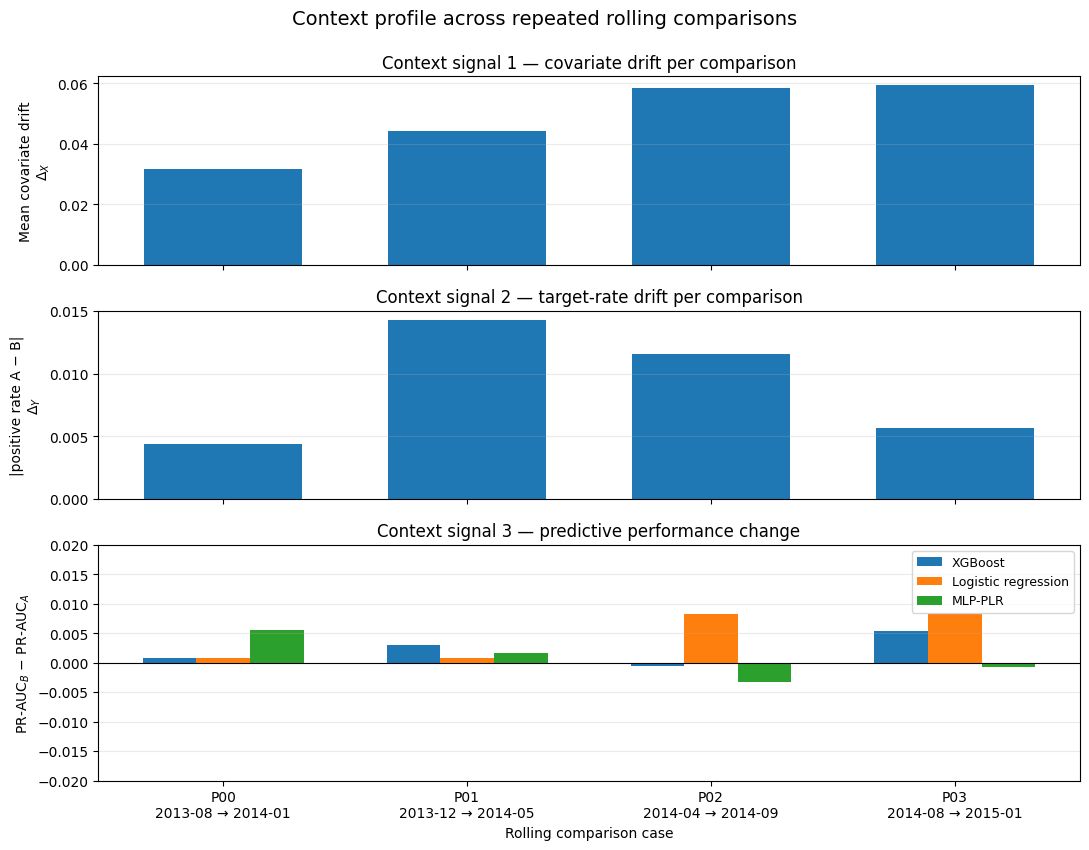

Saved: /content/drive/MyDrive/Thesis/Homesite_workspace/data/results/combined/final_reporting_plots/02_stream_profile_xgboost_shap.png


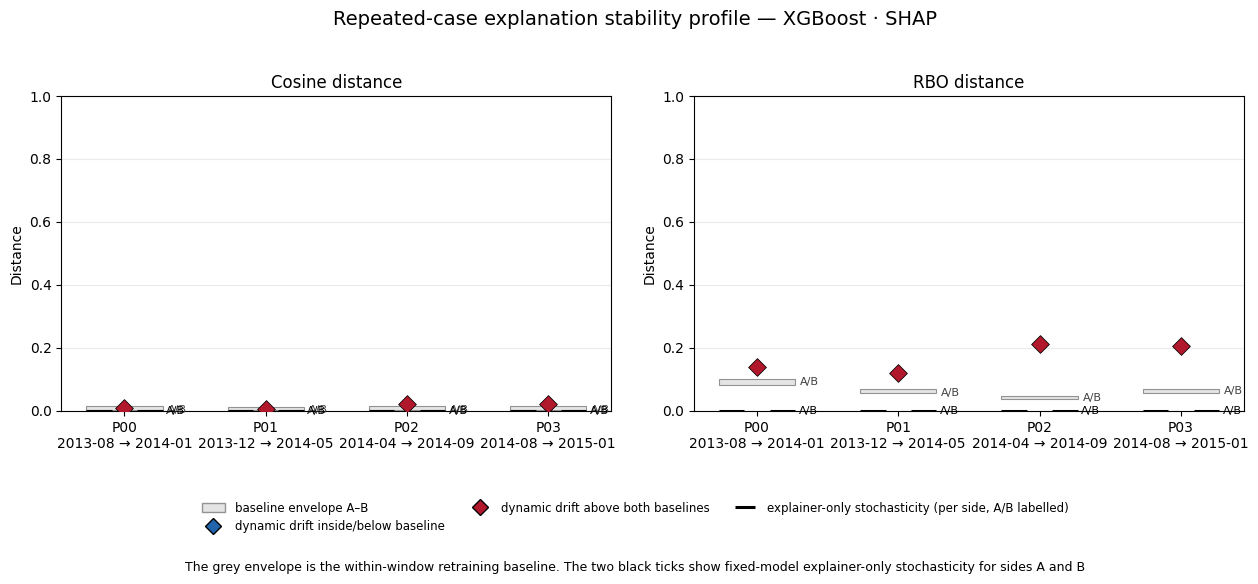

Saved: /content/drive/MyDrive/Thesis/Homesite_workspace/data/results/combined/final_reporting_plots/02_stream_profile_xgboost_lime.png


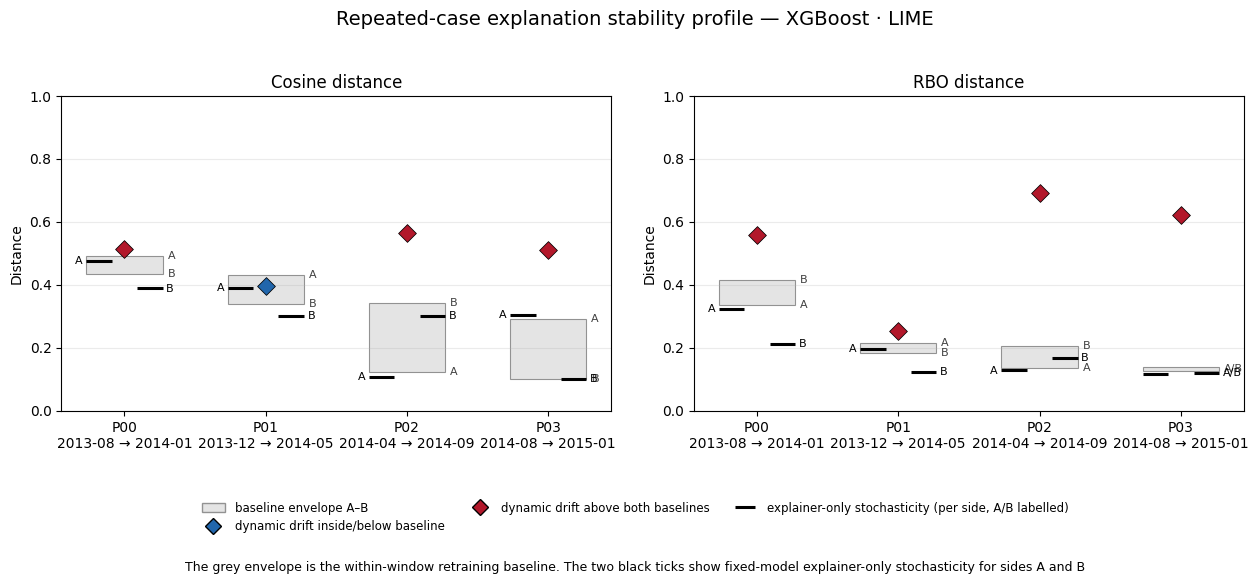

Saved: /content/drive/MyDrive/Thesis/Homesite_workspace/data/results/combined/final_reporting_plots/02_stream_profile_mlp_plr_shap.png


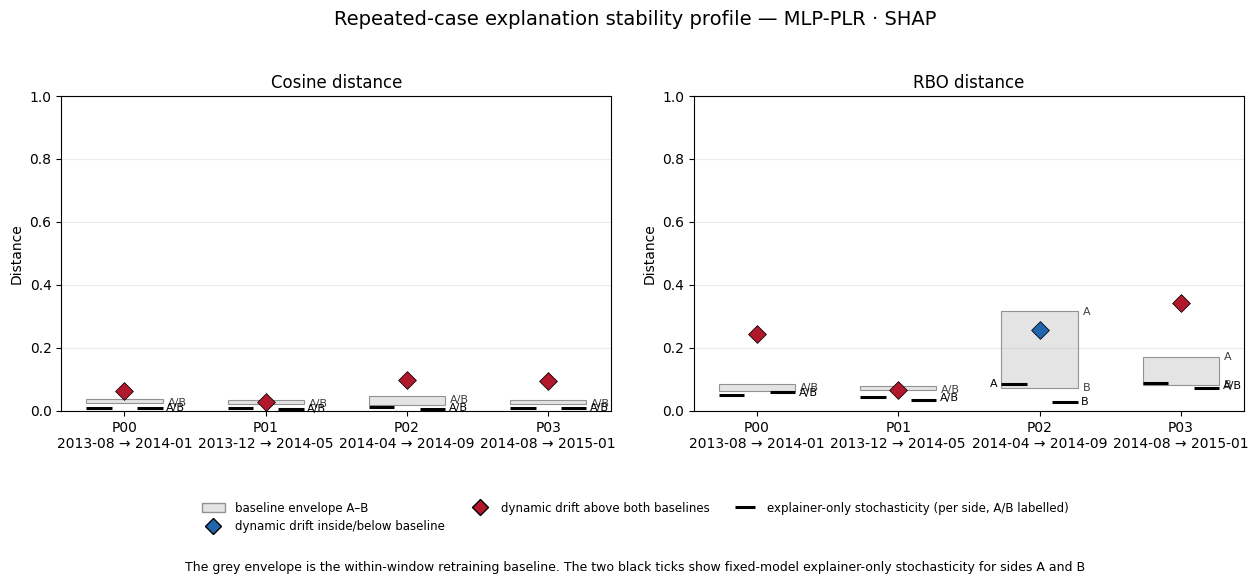

Saved: /content/drive/MyDrive/Thesis/Homesite_workspace/data/results/combined/final_reporting_plots/02_stream_profile_mlp_plr_lime.png


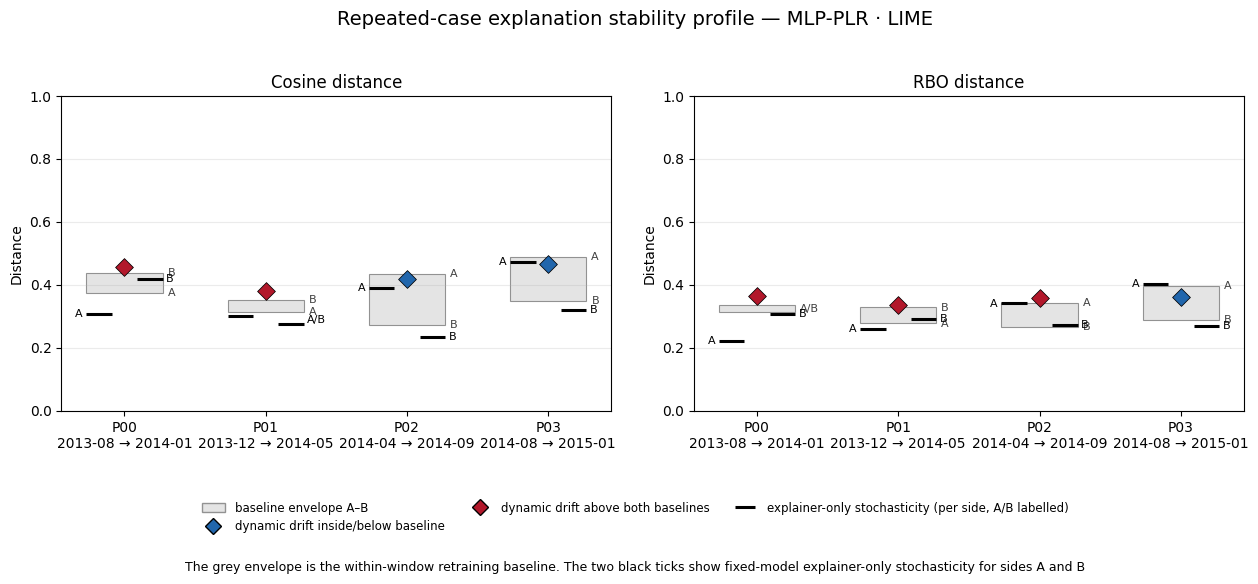

Saved: /content/drive/MyDrive/Thesis/Homesite_workspace/data/results/combined/final_reporting_plots/04_global_shap_drift_cases.png


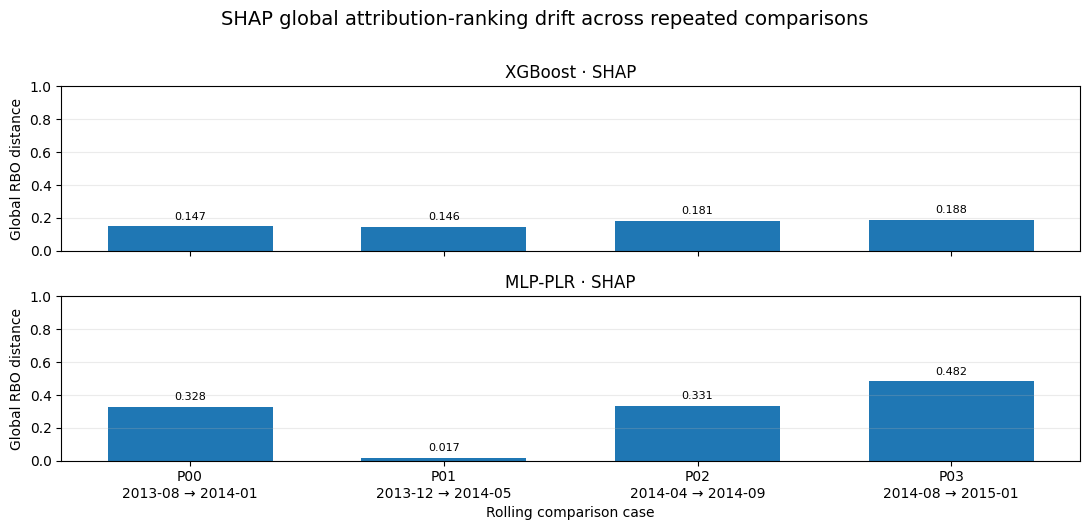

Saved: /content/drive/MyDrive/Thesis/Homesite_workspace/data/results/combined/final_reporting_plots/05_logreg_transparent_reference.png


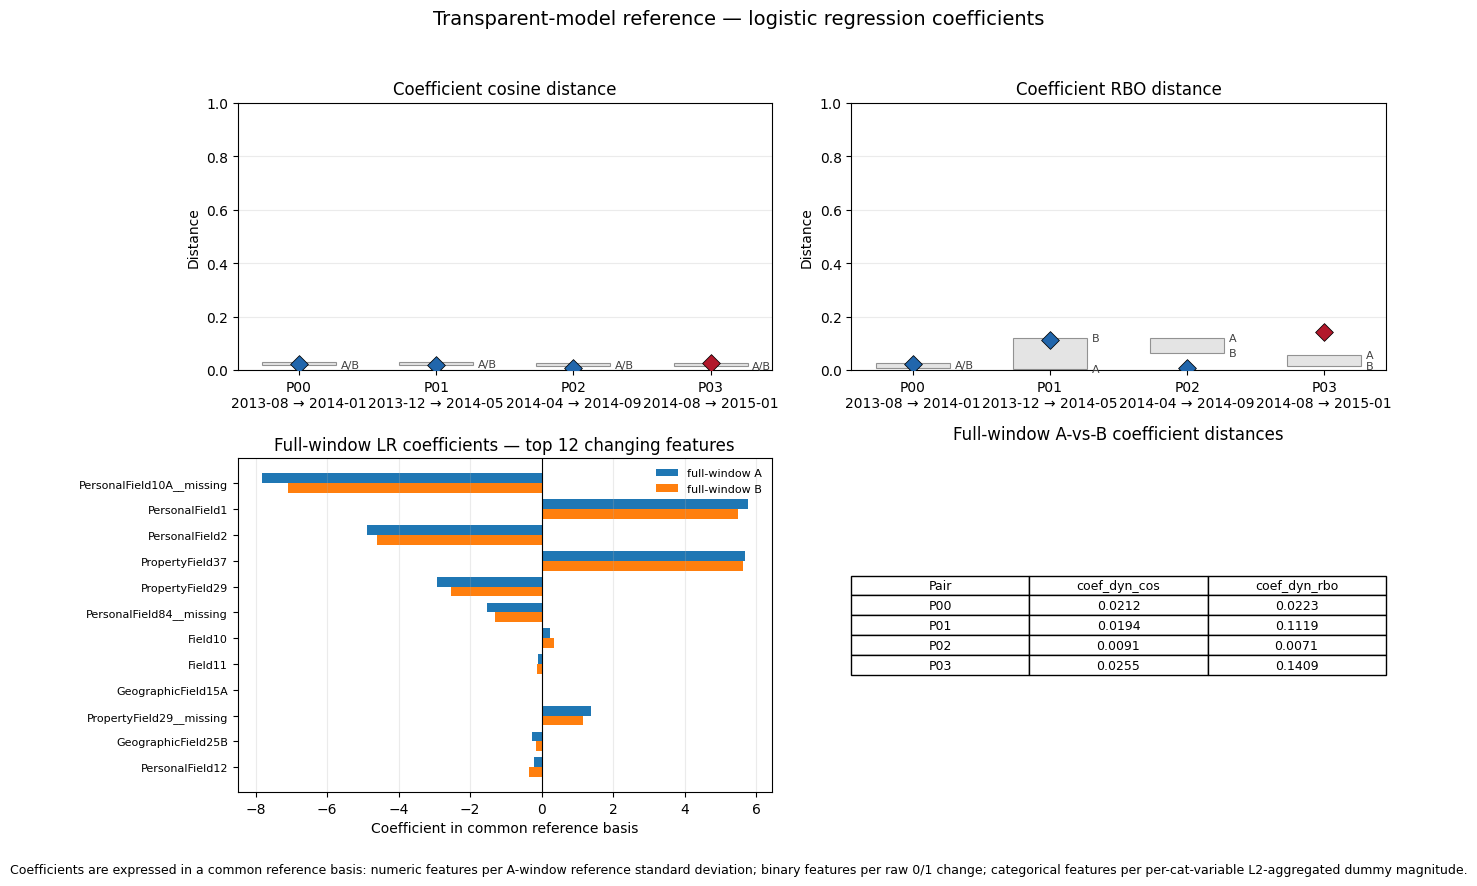


Done.
All final reporting plots saved in: /content/drive/MyDrive/Thesis/Homesite_workspace/data/results/combined/final_reporting_plots


In [9]:
# ============================================================
# Final reporting plots — repeated diagnostic cases, polished
# ============================================================
from matplotlib.patches import Rectangle

try:
    combined_df
except NameError:
    combined_df = pd.read_csv(COMBINED_DIR / 'drift_metrics_combined.csv')

FINAL_PLOT_DIR = COMBINED_DIR / 'final_reporting_plots'
FINAL_PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Final reporting plots will be saved to: {FINAL_PLOT_DIR}')

MODEL_LABELS = {'xgboost': 'XGBoost', 'logreg': 'Logistic regression', 'mlp_plr': 'MLP-PLR'}
EXPLAINER_LABELS = {'shap': 'SHAP', 'lime': 'LIME', 'coef': 'Coefficients'}
POSTHOC_STREAM_ORDER = [('xgboost', 'shap'), ('xgboost', 'lime'),
                       ('mlp_plr', 'shap'), ('mlp_plr', 'lime')]


def _model_label(mt):     return MODEL_LABELS.get(mt, str(mt))
def _explainer_label(e):  return EXPLAINER_LABELS.get(e, str(e))
def _stream_label(mt, e): return f'{_model_label(mt)} · {_explainer_label(e)}'


def _safe_save(fig, path, dpi=180):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'Saved: {path}')


def _comparison_info(df):
    cols = ['pair_id']
    for c in ['step_label_A', 'step_label_B', 'n_eval', 'n_flagged']:
        if c in df.columns:
            cols.append(c)
    info = (df[cols].drop_duplicates('pair_id').sort_values('pair_id').reset_index(drop=True))
    labels = []
    for _, row in info.iterrows():
        pid = int(row['pair_id'])
        if 'step_label_A' in info.columns and 'step_label_B' in info.columns:
            labels.append(f'P{pid:02d}\n{row["step_label_A"]} → {row["step_label_B"]}')
        else:
            labels.append(f'P{pid:02d}')
    info['case_label'] = labels
    return info


def _posthoc_streams(df):
    present = []
    for mt, expl in POSTHOC_STREAM_ORDER:
        sub = df[(df['model_type'] == mt) & (df['explainer'] == expl)]
        if sub.empty:
            continue
        if sub[['loc_cos', 'loc_rbo']].notna().any().any():
            present.append((mt, expl))
    return present


def _aligned_values(sub, pair_ids, col):
    if col not in sub.columns:
        return np.full(len(pair_ids), np.nan, dtype=float)
    s = sub.drop_duplicates('pair_id').set_index('pair_id').reindex(pair_ids)[col]
    return pd.to_numeric(s, errors='coerce').to_numpy(dtype=float)


def _finite_max(*arrays, default=1.0):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        vals.extend(arr[np.isfinite(arr)].tolist())
    return max(vals) if vals else default


def _metric_ylim(metric_name, *arrays):
    max_val = _finite_max(*arrays, default=1.0)
    return 0.0, max(1.0, 1.12 * max_val)


def _symmetric_ylim(ax, values, min_abs=0.02):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    lim = min_abs if len(finite) == 0 else max(min_abs, float(np.max(np.abs(finite))) * 1.15)
    ax.set_ylim(-lim, lim)


def _dynamic_color(loc, base_A, base_B):
    if not np.isfinite(loc):
        return '0.45'
    if np.isfinite(base_A) and np.isfinite(base_B) and loc > max(base_A, base_B):
        return '#b2182b'
    return '#2166ac'


def _draw_baseline_envelope(ax, x, base_A, base_B, y_range, width=0.54, min_height_frac=0.012):
    if not (np.isfinite(base_A) and np.isfinite(base_B)):
        return
    lo = min(base_A, base_B)
    hi = max(base_A, base_B)
    min_h = max(y_range * min_height_frac, 1e-4)
    rect_h = max(hi - lo, min_h)
    rect_y = lo if hi > lo else lo - rect_h / 2
    ax.add_patch(Rectangle((x - width/2, rect_y), width, rect_h,
                            facecolor='0.86', edgecolor='0.45',
                            linewidth=0.8, alpha=0.75, zorder=1))
    close = abs(base_A - base_B) < 0.030 * max(y_range, 1e-8)
    x_text = x + width/2 + 0.035
    if close:
        ax.text(x_text, 0.5*(base_A+base_B), 'A/B', va='center', ha='left',
                fontsize=8, color='0.25', zorder=5)
    else:
        ax.text(x_text, base_A, 'A', va='center', ha='left', fontsize=8, color='0.25', zorder=5)
        ax.text(x_text, base_B, 'B', va='center', ha='left', fontsize=8, color='0.25', zorder=5)


def _draw_stoch_ticks(ax, x, stoch_A, stoch_B, y_range, tick_width=0.18, label_offset=0.025):
    has_A = np.isfinite(stoch_A); has_B = np.isfinite(stoch_B)
    if not (has_A or has_B):
        return
    x_A = x - tick_width; x_B = x + tick_width
    if has_A:
        ax.hlines(y=stoch_A, xmin=x_A - tick_width/2, xmax=x_A + tick_width/2,
                  colors='black', linewidth=2.2, zorder=5)
    if has_B:
        ax.hlines(y=stoch_B, xmin=x_B - tick_width/2, xmax=x_B + tick_width/2,
                  colors='black', linewidth=2.2, zorder=5)
    if has_A and has_B and abs(stoch_A - stoch_B) < 0.030 * max(y_range, 1e-8):
        ax.text(x_B + tick_width/2 + label_offset, 0.5*(stoch_A+stoch_B), 'A/B',
                va='center', ha='left', fontsize=8, color='black', zorder=6)
        return
    if has_A:
        ax.text(x_A - tick_width/2 - label_offset, stoch_A, 'A', va='center', ha='right',
                fontsize=8, color='black', zorder=6)
    if has_B:
        ax.text(x_B + tick_width/2 + label_offset, stoch_B, 'B', va='center', ha='left',
                fontsize=8, color='black', zorder=6)


def _draw_profile_panel(ax, x, labels, loc, base_A, base_B, stoch_A, stoch_B,
                         metric_name, ylabel=None, title=None, show_stoch=True):
    ymin, ymax = _metric_ylim(metric_name, loc, base_A, base_B, stoch_A, stoch_B)
    y_range = ymax - ymin
    for i, xi in enumerate(x):
        _draw_baseline_envelope(ax, xi, base_A[i], base_B[i], y_range)
        ax.scatter(xi, loc[i], marker='D', s=82,
                   color=_dynamic_color(loc[i], base_A[i], base_B[i]),
                   edgecolor='black', linewidth=0.55, zorder=4)
        if show_stoch:
            _draw_stoch_ticks(ax, xi, stoch_A[i], stoch_B[i], y_range)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=0, ha='center')
    ax.grid(axis='y', alpha=0.25); ax.axhline(0, color='black', linewidth=0.6)
    if title:  ax.set_title(title)
    if ylabel: ax.set_ylabel(ylabel)


# ── 1. Context profile ────────────────────────────────────────────────────
def plot_context_cases(df, save_path=None):
    if df is None or df.empty:
        return
    info = _comparison_info(df)
    pair_ids = info['pair_id'].tolist()
    labels = info['case_label'].tolist()
    x = np.arange(len(pair_ids))

    ctx = (df.groupby('pair_id', as_index=False)
             .agg(delta_X=('delta_X', 'mean'), delta_Y=('delta_Y', 'mean'))
             .set_index('pair_id').reindex(pair_ids).reset_index())
    perf = df.drop_duplicates(['model_type', 'pair_id']).sort_values(['model_type', 'pair_id'])
    model_order = [m for m in ['xgboost', 'logreg', 'mlp_plr'] if m in perf['model_type'].unique()]

    fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True,
                              gridspec_kw={'height_ratios': [1.0, 1.0, 1.25]})
    axes[0].bar(x, ctx['delta_X'].values, width=0.65)
    axes[0].set_title('Context signal 1 — covariate drift per comparison')
    axes[0].set_ylabel('Mean covariate drift\n$\\Delta_X$'); axes[0].set_ylim(bottom=0)
    axes[0].grid(axis='y', alpha=0.25)

    axes[1].bar(x, ctx['delta_Y'].values, width=0.65)
    axes[1].set_title('Context signal 2 — target-rate drift per comparison')
    axes[1].set_ylabel('|positive rate A − B|\n$\\Delta_Y$'); axes[1].set_ylim(bottom=0)
    axes[1].grid(axis='y', alpha=0.25)

    ax = axes[2]
    width = min(0.22, 0.80 / max(len(model_order), 1))
    all_perf_vals = []
    for i, mt in enumerate(model_order):
        sub = perf[perf['model_type'] == mt]
        vals = _aligned_values(sub, pair_ids, 'delta_perf')
        all_perf_vals.extend(vals[np.isfinite(vals)].tolist())
        offset = (i - (len(model_order) - 1) / 2) * width
        ax.bar(x + offset, vals, width=width, label=_model_label(mt))
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Context signal 3 — predictive performance change')
    ax.set_ylabel('PR-AUC$_B$ − PR-AUC$_A$')
    ax.grid(axis='y', alpha=0.25)
    _symmetric_ylim(ax, np.array(all_perf_vals, dtype=float), min_abs=0.02)
    ax.legend(loc='best', fontsize=9)
    axes[-1].set_xticks(x); axes[-1].set_xticklabels(labels, rotation=0, ha='center')
    axes[-1].set_xlabel('Rolling comparison case')
    fig.suptitle('Context profile across repeated rolling comparisons', fontsize=14, y=0.995)
    fig.tight_layout()
    if save_path is None:
        save_path = FINAL_PLOT_DIR / '01_context_profile_cases.png'
    _safe_save(fig, save_path); plt.show()


# ── 2. Per-stream stability profiles ──────────────────────────────────────
def plot_stream_diagnostic_profile(df, mt, expl, save_path=None):
    sub = df[(df['model_type'] == mt) & (df['explainer'] == expl)].sort_values('pair_id').copy()
    if sub.empty:
        return
    info = _comparison_info(df)
    pair_ids = info['pair_id'].tolist(); labels = info['case_label'].tolist()
    x = np.arange(len(pair_ids))

    loc_cos      = _aligned_values(sub, pair_ids, 'loc_cos')
    base_cos_A   = _aligned_values(sub, pair_ids, 'base_cos_A')
    base_cos_B   = _aligned_values(sub, pair_ids, 'base_cos_B')
    stoch_cos_A  = _aligned_values(sub, pair_ids, 'stoch_cos_A')
    stoch_cos_B  = _aligned_values(sub, pair_ids, 'stoch_cos_B')
    loc_rbo      = _aligned_values(sub, pair_ids, 'loc_rbo')
    base_rbo_A   = _aligned_values(sub, pair_ids, 'base_rbo_A')
    base_rbo_B   = _aligned_values(sub, pair_ids, 'base_rbo_B')
    stoch_rbo_A  = _aligned_values(sub, pair_ids, 'stoch_rbo_A')
    stoch_rbo_B  = _aligned_values(sub, pair_ids, 'stoch_rbo_B')

    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.9), sharex=True)
    _draw_profile_panel(axes[0], x, labels, loc_cos, base_cos_A, base_cos_B,
                         stoch_cos_A, stoch_cos_B, 'cos',
                         ylabel='Distance', title='Cosine distance', show_stoch=True)
    _draw_profile_panel(axes[1], x, labels, loc_rbo, base_rbo_A, base_rbo_B,
                         stoch_rbo_A, stoch_rbo_B, 'rbo',
                         ylabel='Distance', title='RBO distance', show_stoch=True)

    handles = [
        Rectangle((0, 0), 1, 1, facecolor='0.86', edgecolor='0.45', alpha=0.75,
                  label='baseline envelope A–B'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#2166ac',
                   markeredgecolor='black', markersize=8,
                   label='dynamic drift inside/below baseline'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#b2182b',
                   markeredgecolor='black', markersize=8,
                   label='dynamic drift above both baselines'),
        plt.Line2D([0], [0], marker='_', color='black', linestyle='None',
                   markersize=15, markeredgewidth=2.2,
                   label='explainer-only stochasticity (per side, A/B labelled)'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
                bbox_to_anchor=(0.5, -0.06), fontsize=8.5)
    fig.suptitle(f'Repeated-case explanation stability profile — {_stream_label(mt, expl)}',
                  fontsize=14, y=1.03)
    fig.text(0.5, -0.115,
              'The grey envelope is the within-window retraining baseline. '
              'The two black ticks show fixed-model explainer-only stochasticity for sides A and B',
              ha='center', fontsize=9)
    fig.tight_layout(rect=[0, 0.10, 1, 1])
    if save_path is None:
        save_path = FINAL_PLOT_DIR / f'02_stream_profile_{mt}_{expl}.png'
    _safe_save(fig, save_path); plt.show()


# ── 3. SHAP global drift ──────────────────────────────────────────────────
def plot_global_shap_drift_cases(df, save_path=None):
    if 'global_rbo' not in df.columns:
        return
    shap_df = df[(df['explainer'] == 'shap') & df['global_rbo'].notna()].copy() \
                .sort_values(['model_type', 'pair_id'])
    if shap_df.empty:
        return
    info = _comparison_info(df)
    pair_ids = info['pair_id'].tolist(); labels = info['case_label'].tolist()
    x = np.arange(len(pair_ids))
    model_order = [m for m in ['xgboost', 'mlp_plr'] if m in shap_df['model_type'].unique()]

    fig, axes = plt.subplots(len(model_order), 1,
                              figsize=(11, max(3.0, 2.6 * len(model_order))),
                              sharex=True, squeeze=False)
    axes = axes.ravel()
    for ax, mt in zip(axes, model_order):
        sub = shap_df[shap_df['model_type'] == mt]
        vals = _aligned_values(sub, pair_ids, 'global_rbo')
        ax.bar(x, vals, width=0.65)
        ax.set_title(f'{_model_label(mt)} · SHAP'); ax.set_ylabel('Global RBO distance')
        ax.set_ylim(0, max(1.0, 1.10 * _finite_max(vals, default=1.0)))
        ax.grid(axis='y', alpha=0.25)
        if len(pair_ids) <= 5:
            for xi, val in zip(x, vals):
                if np.isfinite(val):
                    ax.annotate(f'{val:.3f}', xy=(xi, val), xytext=(0, 5),
                                textcoords='offset points', ha='center', fontsize=8)
    axes[-1].set_xticks(x); axes[-1].set_xticklabels(labels, rotation=0, ha='center')
    axes[-1].set_xlabel('Rolling comparison case')
    fig.suptitle('SHAP global attribution-ranking drift across repeated comparisons',
                  fontsize=14, y=1.01)
    fig.tight_layout()
    if save_path is None:
        save_path = FINAL_PLOT_DIR / '04_global_shap_drift_cases.png'
    _safe_save(fig, save_path); plt.show()


# ── 4. LR transparent reference ──────────────────────────────────────────
def plot_lr_transparent_reference(df, feature_names_for_lr, model_dir_base,
                                   top_k=12, save_path=None):
    """feature_names_for_lr is the full (n_num_bin + n_cat) name list; the cat tail
    holds per-cat-variable L2-aggregated entries matching coef_*_full_ref.npy.
    """
    lr = df[(df['model_type'] == 'logreg') & (df['explainer'] == 'coef')].copy().sort_values('pair_id')
    if lr.empty:
        return
    info = _comparison_info(df)
    pair_ids = info['pair_id'].tolist(); labels = info['case_label'].tolist()
    x = np.arange(len(pair_ids))

    coef_dyn_cos = _aligned_values(lr, pair_ids, 'coef_dyn_cos')
    coef_dyn_rbo = _aligned_values(lr, pair_ids, 'coef_dyn_rbo')
    base_cos_A = _aligned_values(lr, pair_ids, 'base_cos_A')
    base_cos_B = _aligned_values(lr, pair_ids, 'base_cos_B')
    base_rbo_A = _aligned_values(lr, pair_ids, 'base_rbo_A')
    base_rbo_B = _aligned_values(lr, pair_ids, 'base_rbo_B')
    nan_arr = np.full(len(pair_ids), np.nan)

    fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0),
                              gridspec_kw={'height_ratios': [1.0, 1.25]})
    _draw_profile_panel(axes[0, 0], x, labels, coef_dyn_cos, base_cos_A, base_cos_B,
                         nan_arr, nan_arr, 'cos',
                         ylabel='Distance', title='Coefficient cosine distance', show_stoch=False)
    _draw_profile_panel(axes[0, 1], x, labels, coef_dyn_rbo, base_rbo_A, base_rbo_B,
                         nan_arr, nan_arr, 'rbo',
                         ylabel='Distance', title='Coefficient RBO distance', show_stoch=False)

    lr_dir_base = Path(model_dir_base) / 'logreg'
    coef_A_list, coef_B_list = [], []
    for pid in pair_ids:
        pair_dir = lr_dir_base / f'pair_{int(pid):02d}'
        a_path = pair_dir / 'coef_A_full_ref.npy'
        b_path = pair_dir / 'coef_B_full_ref.npy'
        if a_path.exists() and b_path.exists():
            coef_A_list.append(np.load(a_path))
            coef_B_list.append(np.load(b_path))

    ax_bar = axes[1, 0]; ax_table = axes[1, 1]
    if not coef_A_list:
        ax_bar.axis('off')
        ax_bar.text(0.5, 0.5,
                    'Full-window LR reference coefficients not found.\n'
                    'Rerun 02_training_replicas.ipynb with MODEL_TYPE="logreg".',
                    ha='center', va='center')
    else:
        coef_A_stack = np.vstack(coef_A_list); coef_B_stack = np.vstack(coef_B_list)
        mean_abs_gap = np.mean(np.abs(coef_A_stack - coef_B_stack), axis=0)
        top_idx = np.argsort(-mean_abs_gap)[:top_k]
        A_mean = coef_A_stack[:, top_idx].mean(axis=0)
        B_mean = coef_B_stack[:, top_idx].mean(axis=0)
        y = np.arange(len(top_idx)); bar_h = 0.38
        ax_bar.barh(y - bar_h/2, A_mean, height=bar_h, label='full-window A')
        ax_bar.barh(y + bar_h/2, B_mean, height=bar_h, label='full-window B')
        ax_bar.axvline(0, color='black', linewidth=0.8)
        ax_bar.set_yticks(y)
        ax_bar.set_yticklabels([feature_names_for_lr[j] for j in top_idx], fontsize=8)
        ax_bar.invert_yaxis()
        ax_bar.set_title(f'Full-window LR coefficients — top {top_k} changing features')
        ax_bar.set_xlabel('Coefficient in common reference basis')
        ax_bar.grid(axis='x', alpha=0.25); ax_bar.legend(frameon=False, fontsize=8)

    ax_table.axis('off')
    table_data = []
    for pid, cv, rv in zip(pair_ids, coef_dyn_cos, coef_dyn_rbo):
        table_data.append([f'P{int(pid):02d}',
                            '-' if not np.isfinite(cv) else f'{cv:.4f}',
                            '-' if not np.isfinite(rv) else f'{rv:.4f}'])
    tab = ax_table.table(cellText=table_data, colLabels=['Pair', 'coef_dyn_cos', 'coef_dyn_rbo'],
                          loc='center', cellLoc='center', colLoc='center')
    tab.auto_set_font_size(False); tab.set_fontsize(9); tab.scale(1.0, 1.25)
    ax_table.set_title('Full-window A-vs-B coefficient distances', pad=14)

    fig.suptitle('Transparent-model reference — logistic regression coefficients',
                  fontsize=14, y=0.995)
    fig.text(0.5, 0.035,
              'Coefficients are expressed in a common reference basis: numeric features per A-window reference standard deviation; '
              'binary features per raw 0/1 change; categorical features per per-cat-variable L2-aggregated dummy magnitude.',
              ha='center', fontsize=9)
    fig.tight_layout(rect=[0, 0.06, 1, 0.97])
    if save_path is None:
        save_path = FINAL_PLOT_DIR / '05_logreg_transparent_reference.png'
    _safe_save(fig, save_path); plt.show()


# ── Run all final reporting plots ────────────────────────────────────────
plot_context_cases(combined_df)
for mt, expl in _posthoc_streams(combined_df):
    plot_stream_diagnostic_profile(combined_df, mt, expl)
plot_global_shap_drift_cases(combined_df)
plot_lr_transparent_reference(combined_df, feature_names_combined, MODEL_DIR_BASE)

print('\nDone.')
print(f'All final reporting plots saved in: {FINAL_PLOT_DIR}')